In [11]:
# Manipulación de datos
import sys
import pandas as pd
from pathlib import Path
import seaborn as sns

BASE_DIR = Path().resolve().parent

# Configuración
sns.set_theme(style="whitegrid")
%matplotlib inline
SEED = 42

---
# Definición del Negocio

In [12]:
df = pd.read_csv(BASE_DIR / 'data' / 'datos_procesados.csv')
#df.info()

El **objetivo de negocio** es predecir si un cliente va a incumplir el pago de su tarjeta de crédito en el siguiente mes, para que la institución financiera pueda tomar acciones preventivas. Esto se traduce en varios objetivos:

**Gestión de riesgo**:Identificar clientes de alto riesgo *antes* de que incumplan, para ajustar límites de crédito, requerir garantías o renegociar condiciones.

**Reducción de pérdidas**: el incumplimiento representa una pérdida directa. Por lo tanto, anticiparlo permite mitigar el impacto financiero.

**Acciones de cobranza proactiva**: Contactar al cliente con tiempo: ofrecer planes de pago, refinanciamiento o alertas antes de que caiga en mora.

**Optimización del portafolio crediticio**: segmentar clientes por nivel de riesgo para diseñar productos financieros más adecuados a cada perfil.

El desarrollo de un modelo que identifique clientes con alto riesgo de morosidad en este contexto de negocio, es un desafío dado que el costo de los errores no es simétrico: un falso negativo, es decir, no detectar a alguien que sí va a incumplir, es más costoso para la institución que un falso positivo, es decir, marcar como riesgoso a alguien que habría pagado. Esto se debe a que un falso negativo implica la pérdida directa del capital prestado, los costos asociados al proceso de cobranza y el eventual castigo contable de la deuda incobrable. En contraste, un falso positivo representa únicamente un costo de oportunidad: los intereses que el cliente habría generado de habérsele otorgado el crédito. En términos prácticos, limitar o negar crédito a un buen cliente supone perder una ganancia futura, mientras que otorgar crédito a un cliente moroso supone perder capital ya comprometido. Por esta razón, métricas como Recall, F1-score y AUC-ROC resultan más adecuadas que la exactitud (accuracy) para evaluar el desempeño del modelo, ya que penalizan con mayor severidad los falsos negativos y reflejan mejor el costo real de los errores para el negocio. 

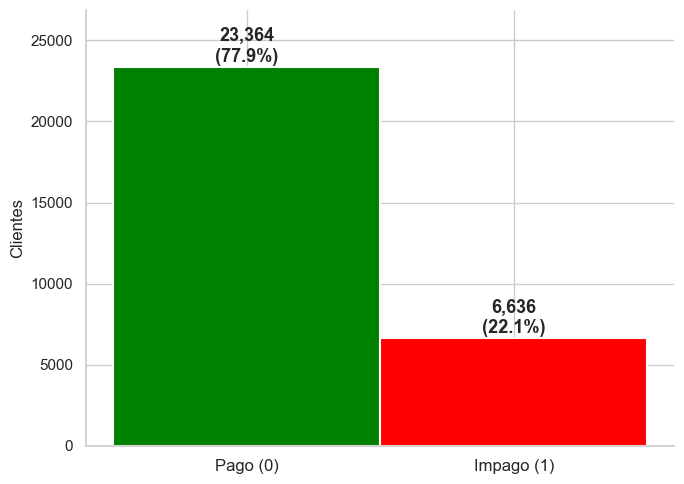

In [13]:
from graficos import grafico_default
grafico_default(df)

Este gráfico muestra la proporción entre pagadores y morosos: mientras que el 77.9% de los clientes (23,364) cumplió con su pago, solo el 22.1% (6,636) incurrió en impago. Esta proporción aproximada de 3.5 a 1 tiene implicaciones directas sobre el modelado, ya que un clasificador trivial que prediga siempre "pago" alcanzaría una exactitud del 77.9% sin ningún poder predictivo real. Por lo tanto, será necesario considerar técnicas de manejo de desbalance de clases —como submuestreo, sobremuestreo o ajuste de pesos— y priorizar métricas sensibles a la clase minoritaria, como el Recall, el F1-score y el AUC-ROC, para una detección efectiva de morosos.

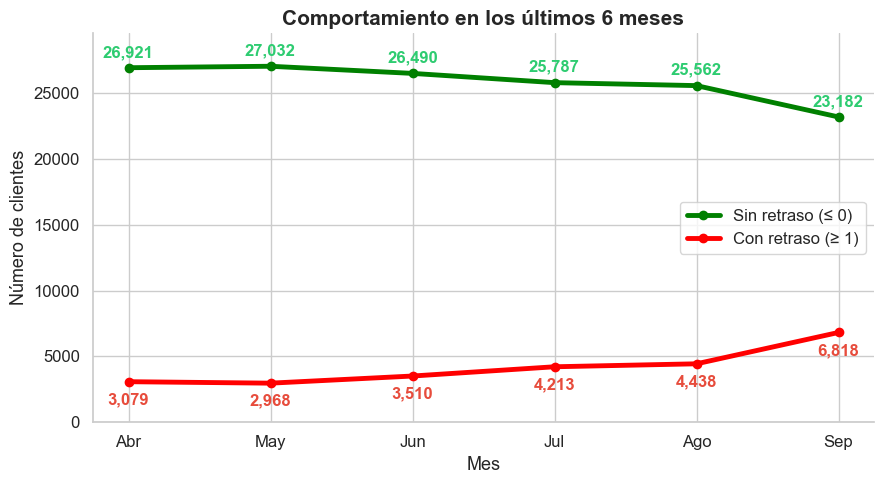

In [14]:
from graficos import grafico_comportamiento
grafico_comportamiento(df)

El análisis del historial de pagos revela una tendencia preocupante a lo largo del período observado: en tan solo seis meses, el porcentaje de clientes con retraso en sus pagos pasó del 10.3% al 22.7%, prácticamente duplicándose entre abril y septiembre. En sentido contrario, los clientes al corriente disminuyeron de 26,921 a 23,182 en el mismo período. Este deterioro progresivo del comportamiento de pago sugiere que la morosidad no es un evento aislado, sino un proceso que se agrava con el tiempo, lo que refuerza la utilidad de incluir el historial de pagos (comportamiento) de los meses previos como variables predictoras clave en el modelo.

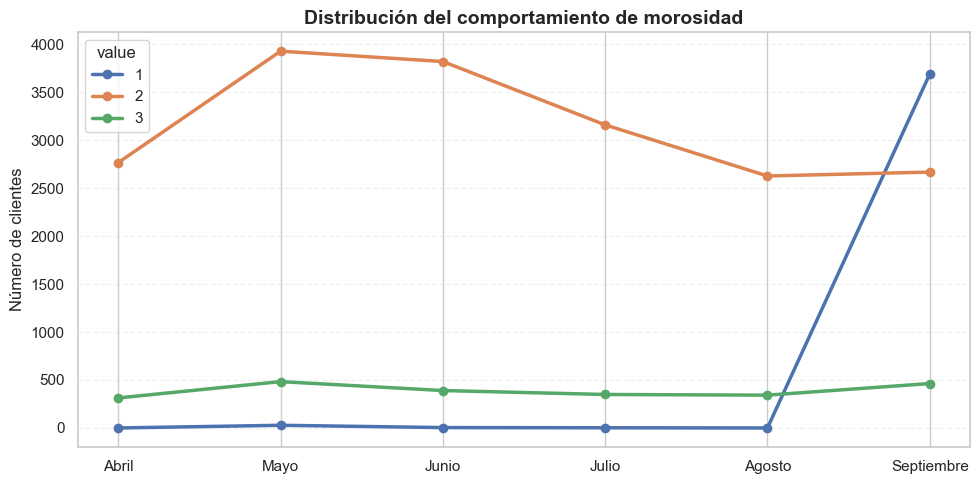

In [15]:
from graficos import grafico_morosidad
grafico_morosidad(df)

El análisis de la distribución de morosidad a lo largo del período revela patrones específicos para la construcción del modelo. Principalmente, la tendencia de los clientes con un mes de retraso muestra un cambio crítico de comportamiento entre agosto y septiembre, pasando de 28 a 3688 clientes, es decir, 131 veces más clientes que el mes anterior. Esto representa un problema cuyo origen puede tener múltiples razones; primero, este comportamiento no responde a una tendencia orgánica de deterioro gradual, sino que puede ser un problema en la recolección de los datos o en la codificación del comportamiento del último mes. Sin embargo, tampoco se descarta que sea resultado específico de un fenómeno de contracción económica puntual.

La categoría de **2 meses de retraso** es la más frecuente durante todo el período, aunque muestra una tendencia descendente sostenida desde mayo (3,938) hasta agosto (2,632) con aumento mínimo en septiembre, lo que podría sugerir una mejora parcial en el comportamiento de pago de este segmento.

Por último, La categoría de **retraso severo (≥3 meses)** se mantiene relativamente estable y baja con menos de 500 clientes por mes, lo que indica que los clientes con morosidad crónica representan una fracción pequeña pero consistente del portafolio.


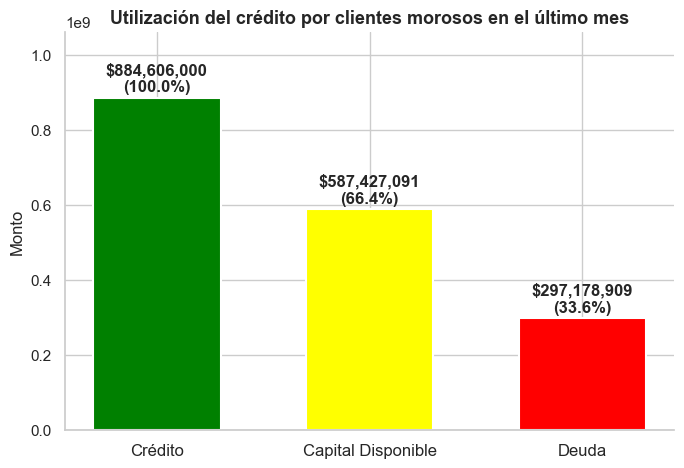

In [16]:
from graficos import grafico_utilizacion_credito
grafico_utilizacion_credito(df)

En conjunto, los clientes que incurrieron en impago el mes siguiente tenían comprometido el **33.6% de su límite de crédito total** ($297,178,909 de un total de $884,606,000), manteniendo aún un 66.4% de capital disponible. A primera vista esto podría interpretarse como un nivel de endeudamiento moderado; sin embargo, este agregado oculta la heterogeneidad del portafolio, ya que promediar clientes con alta y baja utilización del crédito puede subestimar el riesgo real de los segmentos más comprometidos. Por ello, la **tasa de utilización del crédito** a nivel individual —calculada como la razón entre la deuda y el límite otorgado— resulta una variable potencialmente más informativa para el modelo que los montos absolutos.

---

# Conclusión

A partir del análisis del comportamiento de los clientes, se identificaron los elementos que condicionarán las decisiones de modelado. El dataset presenta un **desbalance de clases moderado** (77.9% vs 22.1%) que descarta el uso de **accuracy** como métrica principal y justifica el uso de técnicas de balanceo o ajuste de pesos. El **historial de comportamiento de pago** emerge como la dimensión más informativa, dado que la morosidad muestra un deterioro progresivo y sostenido a lo largo del período, lo que sugiere que las variables de comportamiento de los meses previos tendrán alto poder predictivo. No obstante, la anomalía detectada en `comportamiento_septiembre` —con un salto de 28 a 3,688 clientes en la categoría de 1 mes de retraso— introduce incertidumbre sobre la calidad de esta variable y deberá monitorearse durante el modelado. Finalmente, la tasa de utilización del crédito a nivel individual se identifica como una variable derivada con potencial predictivo superior a los montos absolutos de deuda.

En conjunto, estos hallazgos orientan hacia un modelo que priorice el **Recall** y el **AUC-ROC** como métricas de evaluación, que incorpore el historial de comportamiento como bloque de variables principal, y que sea robusto frente a posibles inconsistencias en la codificación de los datos.